<a href="https://colab.research.google.com/github/hst8486-collab/thuc-hanh--deep-learning/blob/main/B%C3%A0i_th%E1%BB%B1c_h%C3%A0nh_tu%E1%BA%A7n_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Bài Tập Mô Hình Hồi Quy: Dự Đoán Giá Nhà

 Xây dựng mô hình hồi quy để dự đoán giá nhà dựa trên các đặc trưng khác nhau.



### Bước 1: Import thư viện


In [ ]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Hiện toàn bộ dữ liệu trong Colab
pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns',None)

### Bước 2: Dữ liệu


In [ ]:
url="https://raw.githubusercontent.com/huynhhoc/DataAnalystDeepLearning/main/Data/23_HOMES.csv"

df=pd.read_csv(url)

print("Kích thước dữ liệu:")

print(df.shape)

print("\nToàn bộ dữ liệu:")

display(df)

print("\nTên các cột:")

print(df.columns.tolist())

Kích thước dữ liệu:
(40, 9)

Toàn bộ dữ liệu:


,Selling_Price,List_Price,Area,Acres,Age,Taxes,Rooms,Bedrooms,Baths_full
0,400000,414000,2704,2.27,27,4920,9,3,3
1,370000,379000,2096,0.75,21,4113,8,4,2
2,382500,389900,2737,1.00,36,6072,9,4,2
3,300000,299900,1800,0.43,34,4024,8,4,2
4,305000,319900,1066,3.60,69,3562,6,3,2
5,320000,319900,1820,1.70,34,4672,7,3,2
6,321000,328900,2700,0.81,35,3645,8,3,1
7,445000,450000,2316,2.00,19,6256,9,4,2
8,377500,385000,2448,1.50,40,5469,9,4,3
9,460000,479000,3040,1.09,20,6740,10,4,2



Tên các cột:
['Selling_Price', 'List_Price', 'Area', 'Acres', 'Age', 'Taxes', 'Rooms', 'Bedrooms', 'Baths_full']


### Bước 3: Kiểm tra dữ liệu


In [ ]:
print("Thông tin dữ liệu")

df.info()

print("\nKiểm tra giá trị thiếu")

display(df.isnull().sum())

print("\nThống kê mô tả")

display(df.describe())


Thông tin dữ liệu
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Selling_Price  40 non-null     int64  
 1   List_Price     40 non-null     int64  
 2   Area           40 non-null     int64  
 3   Acres          40 non-null     float64
 4   Age            40 non-null     int64  
 5   Taxes          40 non-null     int64  
 6   Rooms          40 non-null     int64  
 7   Bedrooms       40 non-null     int64  
 8   Baths_full     40 non-null     int64  
dtypes: float64(1), int64(8)
memory usage: 2.9 KB

Kiểm tra giá trị thiếu


,0
Selling_Price,0
List_Price,0
Area,0
Acres,0
Age,0
Taxes,0
Rooms,0
Bedrooms,0
Baths_full,0



Thống kê mô tả


,Selling_Price,List_Price,Area,Acres,Age,Taxes,Rooms,Bedrooms,Baths_full
count,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000
mean,342672.500000,349937.500000,2058.375000,1.690250,38.125000,4626.625000,7.675000,3.300000,1.900000
std,83236.659784,84592.348831,657.934674,2.007324,22.944959,1848.538947,1.654636,0.723241,0.744208
min,210000.000000,219900.000000,1066.000000,0.250000,6.000000,1367.000000,4.000000,2.000000,1.000000
25%,292000.000000,294975.000000,1646.250000,0.667500,24.750000,3479.750000,6.000000,3.000000,1.000000
50%,309000.000000,319900.000000,1855.000000,1.000000,35.500000,4129.500000,8.000000,3.000000,2.000000
75%,388750.000000,395925.000000,2412.000000,1.880000,46.250000,5530.250000,9.000000,4.000000,2.000000
max,520000.000000,529700.000000,3867.000000,11.580000,144.000000,9809.000000,11.000000,5.000000,4.000000


### Bước 4: Trực quan hóa dữ liệu



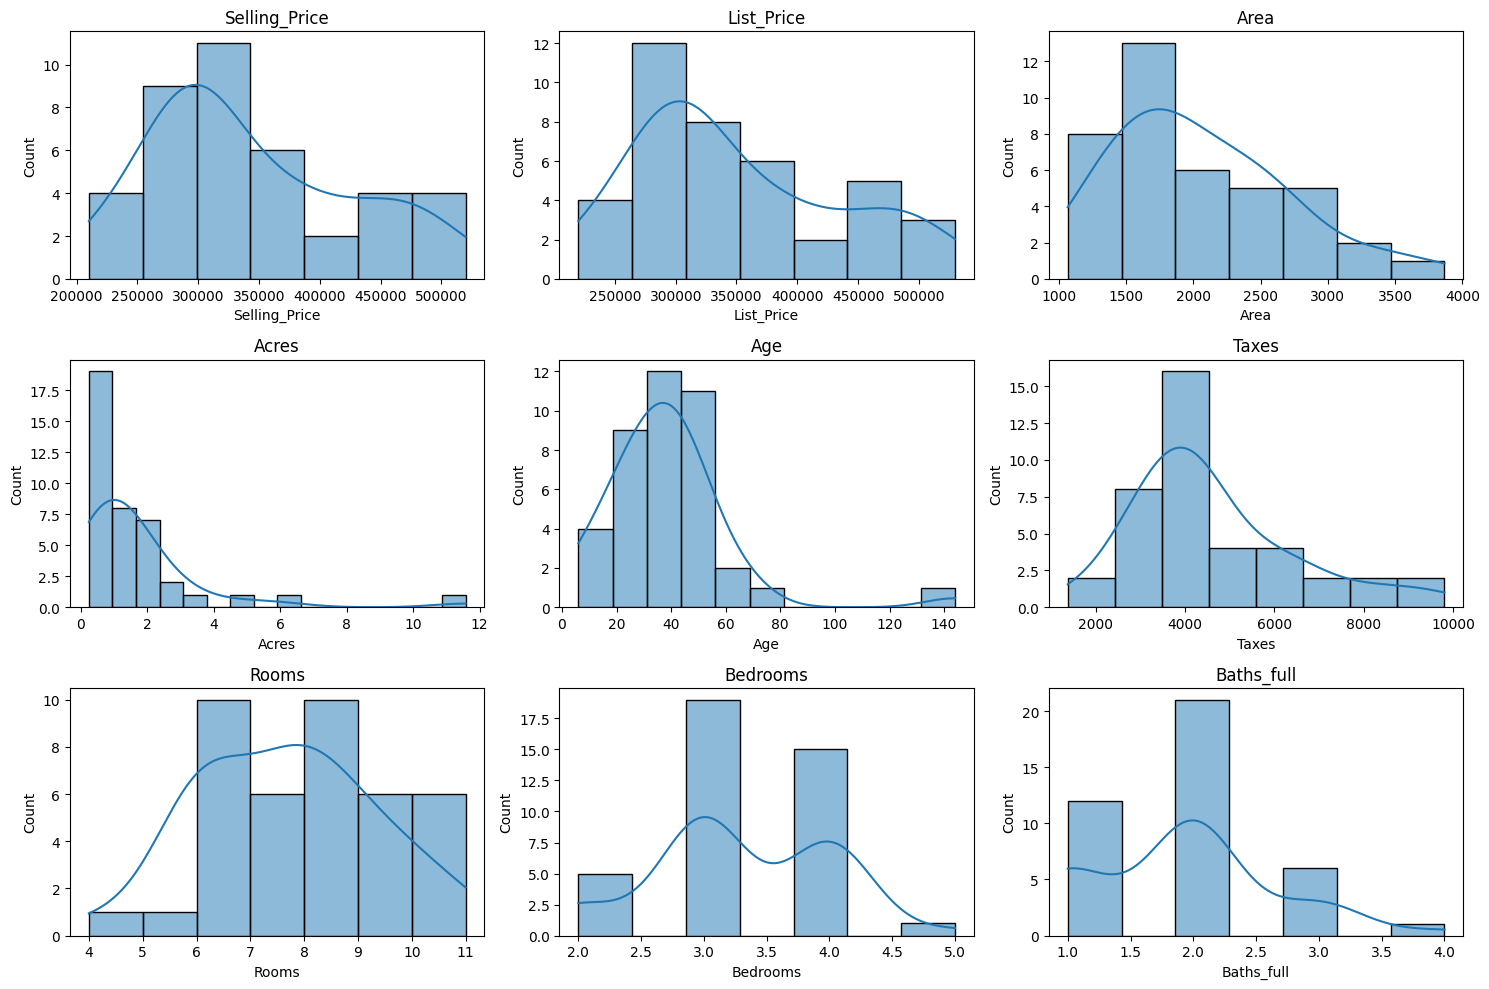

In [ ]:
plt.figure(figsize=(15,10))

for i,col in enumerate(df.columns):

    plt.subplot(3,3,i+1)

    sns.histplot(
        data=df,
        x=col,
        kde=True
    )

    plt.title(col)

plt.tight_layout()

plt.show()

### Bước 5:Heatmap tương quan



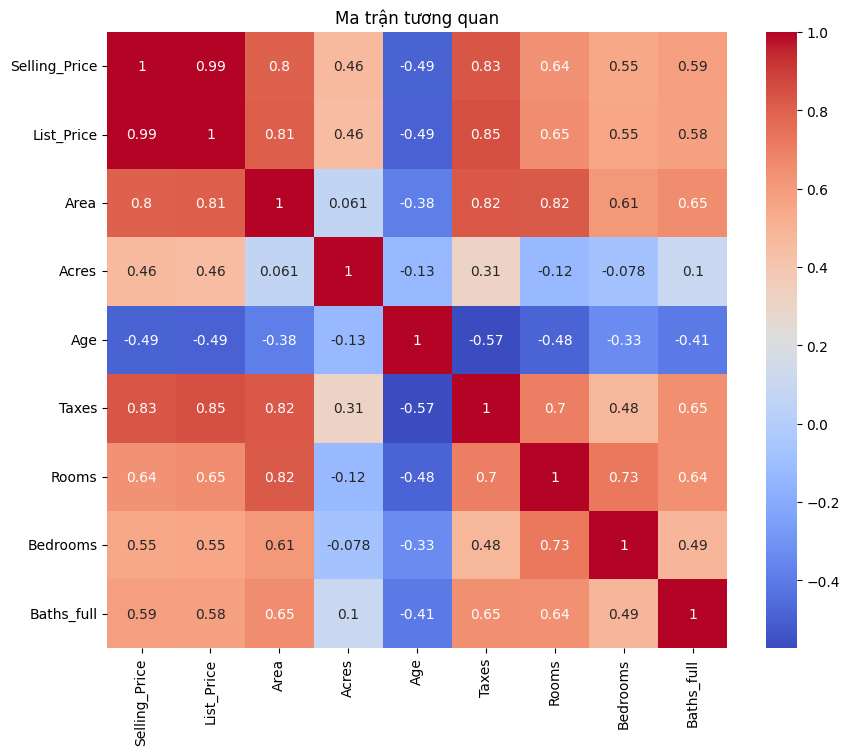

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(

    df.corr(),
    annot=True,
    cmap='coolwarm'

)

plt.title(
    "Ma trận tương quan"
)

plt.show()

### Bước 6: Chia dữ liệu



In [ ]:
X=df.drop(

    "Selling_Price",
    axis=1

)

y=df["Selling_Price"]

print("Kích thước X")

print(X.shape)

print("\nKích thước y")

print(y.shape)

Kích thước X
(40, 8)

Kích thước y
(40,)


# Bước 7: Train và Test

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42

)

print(

    "Train:",

    X_train.shape

)

print(

    "Test:",

    X_test.shape

)

Train: (32, 8)
Test: (8, 8)


### Bước 8: Linear Regression



In [ ]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

y_pred_linear = linear_model.predict(
    X_test
)

print(
    "Linear Regression huấn luyện thành công"
)

Linear Regression huấn luyện thành công


# Bước 9: Radom forest

In [ ]:
rf = RandomForestRegressor(

    n_estimators=200,

    random_state=42

)

rf.fit(

    X_train,
    y_train

)

y_pred_rf = rf.predict(
    X_test
)

print(
    "Random Forest huấn luyện thành công"
)

Random Forest huấn luyện thành công


# Bước 10: Hàm đánh giá

In [ ]:
def show_calculation(
    y_true,
    y_pred,
    model_name
):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    mse = mean_squared_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mse
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    print("\n===================")
    print(model_name)
    print("===================")

    print(f"MAE : {mae:.2f}")
    print(f"MSE : {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²  : {r2:.4f}")

    return [model_name,mae,rmse,r2]

# Bước 11: So sánh mô hình

In [ ]:
linear_result = show_calculation(

    y_test,
    y_pred_linear,
    "Linear Regression"

)

rf_result = show_calculation(

    y_test,
    y_pred_rf,
    "Random Forest"

)

comparison = pd.DataFrame(

    [linear_result,rf_result],

    columns=[

        "Model",
        "MAE",
        "RMSE",
        "R2"

    ]

)

display(comparison)


Linear Regression
MAE : 4228.15
MSE : 35041495.01
RMSE: 5919.59
R²  : 0.9952

Random Forest
MAE : 21396.75
MSE : 1143581018.62
RMSE: 33816.87
R²  : 0.8418


,Model,MAE,RMSE,R2
0,Linear Regression,4228.145678,5919.585712,0.995153
1,Random Forest,21396.750000,33816.874761,0.841821


# Bước 12: Biểu đồ so sánh

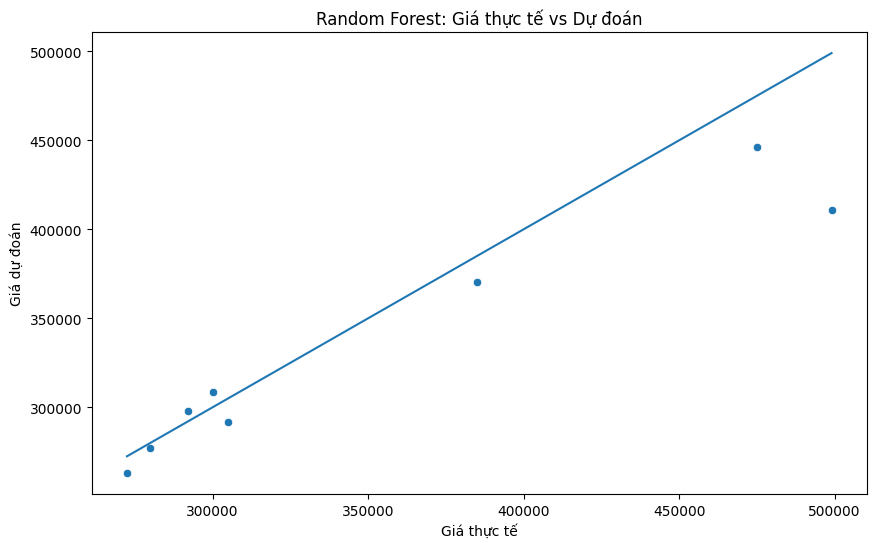

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=y_test,
    y=y_pred_rf
)

plt.xlabel(
    "Giá thực tế"
)

plt.ylabel(
    "Giá dự đoán"
)

plt.title(
    "Random Forest: Giá thực tế vs Dự đoán"
)

plt.plot(

    [y_test.min(),y_test.max()],
    [y_test.min(),y_test.max()]

)

plt.show()


# Bước 13: Dự đoán giá nhà mới

In [ ]:
new_house=pd.DataFrame({

'List_Price':[420000],

'Area':[2500],

'Acres':[1.2],

'Age':[10],

'Taxes':[4500],

'Rooms':[8],

'Bedrooms':[4],

'Baths_full':[3]

})

predicted_price=rf.predict(
    new_house
)

print(

f"Giá dự đoán: ${predicted_price[0]:,.0f}"

)

Giá dự đoán: $407,000


# BÀI TẬP ANN: DỰ ĐOÁN GIÁ NHÀ

# Bước 1: Import thư viện

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Bước 2: Lấy dữ liệu

In [ ]:
url="https://raw.githubusercontent.com/huynhhoc/DataAnalystDeepLearning/main/Data/23_HOMES.csv"

df=pd.read_csv(url)

pd.set_option(
    'display.max_columns',
    None
)

pd.set_option(
    'display.max_rows',
    None
)

display(df)

print(
    "\nKích thước dữ liệu:"
)

print(df.shape)

,Selling_Price,List_Price,Area,Acres,Age,Taxes,Rooms,Bedrooms,Baths_full
0,400000,414000,2704,2.27,27,4920,9,3,3
1,370000,379000,2096,0.75,21,4113,8,4,2
2,382500,389900,2737,1.00,36,6072,9,4,2
3,300000,299900,1800,0.43,34,4024,8,4,2
4,305000,319900,1066,3.60,69,3562,6,3,2
5,320000,319900,1820,1.70,34,4672,7,3,2
6,321000,328900,2700,0.81,35,3645,8,3,1
7,445000,450000,2316,2.00,19,6256,9,4,2
8,377500,385000,2448,1.50,40,5469,9,4,3
9,460000,479000,3040,1.09,20,6740,10,4,2



Kích thước dữ liệu:
(40, 9)


# Bước 3: Kiểm tra dữ liệu

In [ ]:
print(
    "Thông tin dữ liệu:"
)

df.info()

print(
    "\nDữ liệu thiếu:"
)

display(
    df.isnull().sum()
)

print(
    "\nThống kê:"
)

display(
    df.describe()
)

Thông tin dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Selling_Price  40 non-null     int64  
 1   List_Price     40 non-null     int64  
 2   Area           40 non-null     int64  
 3   Acres          40 non-null     float64
 4   Age            40 non-null     int64  
 5   Taxes          40 non-null     int64  
 6   Rooms          40 non-null     int64  
 7   Bedrooms       40 non-null     int64  
 8   Baths_full     40 non-null     int64  
dtypes: float64(1), int64(8)
memory usage: 2.9 KB

Dữ liệu thiếu:


,0
Selling_Price,0
List_Price,0
Area,0
Acres,0
Age,0
Taxes,0
Rooms,0
Bedrooms,0
Baths_full,0



Thống kê:


,Selling_Price,List_Price,Area,Acres,Age,Taxes,Rooms,Bedrooms,Baths_full
count,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000
mean,342672.500000,349937.500000,2058.375000,1.690250,38.125000,4626.625000,7.675000,3.300000,1.900000
std,83236.659784,84592.348831,657.934674,2.007324,22.944959,1848.538947,1.654636,0.723241,0.744208
min,210000.000000,219900.000000,1066.000000,0.250000,6.000000,1367.000000,4.000000,2.000000,1.000000
25%,292000.000000,294975.000000,1646.250000,0.667500,24.750000,3479.750000,6.000000,3.000000,1.000000
50%,309000.000000,319900.000000,1855.000000,1.000000,35.500000,4129.500000,8.000000,3.000000,2.000000
75%,388750.000000,395925.000000,2412.000000,1.880000,46.250000,5530.250000,9.000000,4.000000,2.000000
max,520000.000000,529700.000000,3867.000000,11.580000,144.000000,9809.000000,11.000000,5.000000,4.000000


# Bước 4: Heatmap tương quan

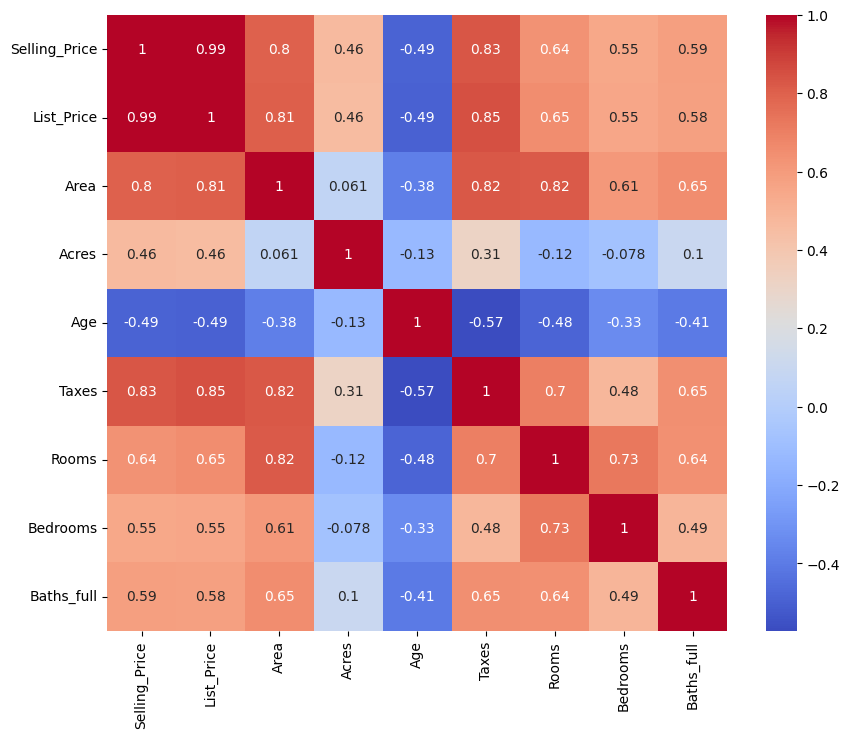

In [ ]:
plt.figure(
    figsize=(10,8)
)

sns.heatmap(

    df.corr(),
    annot=True,
    cmap='coolwarm'

)

plt.show()

# Bước 5: Chia X/Y

In [ ]:
X=df.drop(

    "Selling_Price",
    axis=1

)

y=df["Selling_Price"]

print(
    X.shape
)

print(
    y.shape
)

(40, 8)
(40,)


# Bước 6: Chia tập train / test

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42

)

print(
    "Train:",
    X_train.shape
)

print(
    "Test:",
    X_test.shape
)

Train: (32, 8)
Test: (8, 8)


# Bước 7: Chuẩn hóa dữ liệu

In [ ]:
scaler=StandardScaler()

X_train=scaler.fit_transform(
    X_train
)

X_test=scaler.transform(
    X_test
)

print(
    "Chuẩn hóa thành công"
)

Chuẩn hóa thành công


# Bước 8: Ann

In [ ]:
model=Sequential()

# Hidden Layer 1

model.add(

    Dense(

        64,

        activation='relu',

        input_dim=X_train.shape[1]

    )

)

# Hidden Layer 2

model.add(

    Dense(

        32,

        activation='relu'

    )

)

# Output Layer

model.add(

    Dense(

        1

    )

)

model.compile(

    optimizer='adam',

    loss='mse',

    metrics=['mae']

)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

# Bước 9: Huấn luyện Ann

In [ ]:
history=model.fit(

    X_train,
    y_train,

    epochs=100,

    batch_size=8,

    validation_split=0.2,

    verbose=1
)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 220ms/step - loss: 126227316736.0000 - mae: 347340.3125 - val_loss: 109672996864.0000 - val_mae: 316414.4688
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 146ms/step - loss: 126227193856.0000 - mae: 347340.1562 - val_loss: 109672882176.0000 - val_mae: 316414.2812
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 126227103744.0000 - mae: 347340.0312 - val_loss: 109672783872.0000 - val_mae: 316414.0625
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 126227005440.0000 - mae: 347339.8750 - val_loss: 109672677376.0000 - val_mae: 316413.9688
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 126226915328.0000 - mae: 347339.7500 - val_loss: 109672603648.0000 - val_mae: 316413.7812
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - loss: 126226833408.0000 - mae: 347339.6250 - val_loss: 109672521728.0000 - val_mae: 316413.6875
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 186ms/step - loss: 126226759680.0000 - mae: 347339.5312 - val_loss: 1

# Bước 10: Dự đoán

In [ ]:
y_pred=model.predict(
    X_test
)

y_pred=y_pred.flatten()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


# Bước 11: Đánh giá model

In [ ]:
mae=mean_absolute_error(
    y_test,
    y_pred
)

mse=mean_squared_error(
    y_test,
    y_pred
)

rmse=np.sqrt(
    mse
)

r2=r2_score(
    y_test,
    y_pred
)

print(
    "===== KẾT QUẢ ====="
)

print(
    f"MAE: {mae:.2f}"
)

print(
    f"MSE: {mse:.2f}"
)

print(
    f"RMSE: {rmse:.2f}"
)

print(
    f"R²: {r2:.4f}"
)

===== KẾT QUẢ =====
MAE: 350565.44
MSE: 130098528256.00
RMSE: 360691.74
R²: -16.9951


# Bước 12: Loss của ANN

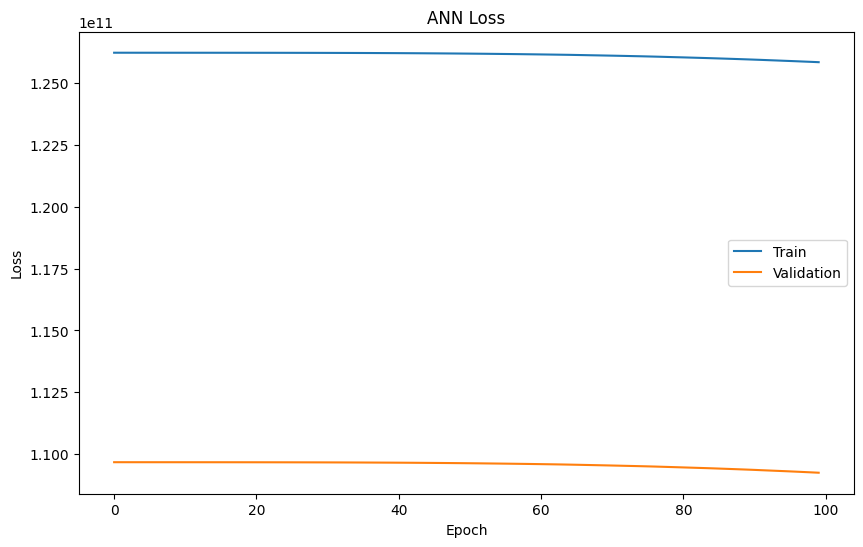

In [ ]:
plt.figure(
    figsize=(10,6)
)

plt.plot(
    history.history['loss']
)

plt.plot(
    history.history['val_loss']
)

plt.legend(
    ['Train','Validation']
)

plt.xlabel(
    'Epoch'
)

plt.ylabel(
    'Loss'
)

plt.title(
    'ANN Loss'
)

plt.show()

# Bước 13: Dự đoán giá nhà

In [ ]:
new_house=pd.DataFrame({

'List_Price':[420000],
'Area':[2500],
'Acres':[1.2],
'Age':[10],
'Taxes':[4500],
'Rooms':[8],
'Bedrooms':[4],
'Baths_full':[3]

})

new_house=scaler.transform(
    new_house
)

predicted_price=model.predict(
    new_house
)

print(

f"Giá dự đoán: ${predicted_price[0][0]:,.0f}"

)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Giá dự đoán: $565
